# Animation Market Insight

## Introduction

This notebook documents the analytical workflow behind the static website. It loads and processes the dataset, transforms it for the three research questions, produces the core visualizations.

The project compares **animation** and **non-animation**. It uses **Wikidata as Linked Open Data**, supplemented by IMDb non-commercial datasets and annual worldwide box-office rankings from Box Office Mojo.

## Table of contents

1. Research questions
2. Data sources and setup
3. Raw IMDb processing
4. RQ1 — Animated share in four IMDb market samples
5. RQ2 — Worldwide box-office performance
6. RQ3 — Production companies behind top animated films
7. Appendix, limitations and conclusions

## 1. Research questions

**RQ1 — Market presence**  
What share of films released in Mainland China, North America (United States/Canada), Japan and France were animated from 2016 to 2025?

**RQ2 — Box-office performance**  
How does the worldwide box-office performance of top animated films compare with top non-animated films from 2016 to 2025?

**RQ3 — Production company landscape**  
Which production companies are behind the top animated films, and do companies such as Disney, Pixar and Marvel still dominate the market?

## 2. Data sources

### Wikidata — Linked Open Data
Films are joined to Wikidata by specific IMDb ID using Wikidata property P345. Wikidata provides the film entity (QID), country and production-company metadata used in RQ3. 

### IMDb non-commercial datasets
IMDb title.akas lists alternative and localized titles, together with the region code associated with each title record. A title is classified as animated when its IMDb genres field contains Animation.

For RQ1, a movie is included in a market sample when IMDb lists at least one title for that market. 

The North American sample combines US and Canadian title records. Films appearing in both are counted only once.

### Box Office Mojo
The annual worldwide ranking pages for 2016–2025 were downloaded as HTML. The project extraction script kept ranks 1–20 and related year, rank, title, worldwide gross and release-group URL. 

### Analytical files
- data/processed/imdb_market_animation_share_2016_2025.csv
- data/processed/rq2_top20_worldwide_2016_2025.csv

In [ ]:
from collections import defaultdict
from pathlib import Path
import csv
import gzip

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import PercentFormatter


ROOT = Path.cwd()
if not (ROOT / "data" / "processed").exists():
    candidate = ROOT / "reel-numbers"
    if (candidate / "data" / "processed").exists():
        ROOT = candidate

MARKET_PATH = ROOT / "data" / "processed" / "imdb_market_animation_share_2016_2025.csv"
TOP20_PATH = ROOT / "data" / "processed" / "rq2_top20_worldwide_2016_2025.csv"


def find_imdb_source(stem):
    candidates = [
        ROOT / "data" / "raw" / "imdb" / f"{stem}.tsv.gz",
        ROOT / "data" / "raw" / "imdb" / f"{stem}.tsv",
    ]
    return next((path for path in candidates if path.exists()), candidates[0])


IMDB_BASICS_PATH = find_imdb_source("title.basics")
IMDB_AKAS_PATH = find_imdb_source("title.akas")

assert TOP20_PATH.exists(), f"Missing data file: {TOP20_PATH}"

MARKET_ORDER = ["NA", "CN", "JP", "FR"]
MARKET_COLORS = {"NA": "#111111", "CN": "#7759f6", "JP": "#e94f3a", "FR": "#2248bd"}
TYPE_COLORS = {"Animated": "#111111", "Non-animated": "#bdbdbd"}
EXPECTED_YEARS = list(range(2016, 2026))

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 30)

## 3. Process the raw IMDb files and validate the data

### 3.1 RQ1 input files

Download `title.basics.tsv.gz` and `title.akas.tsv.gz` from the [IMDb non-commercial datasets](https://developer.imdb.com/non-commercial-datasets/) and place them in `data/raw/imdb/`. The code accepts either the original `.tsv.gz` files or browser-extracted `.tsv` files.

`title.basics` provides the IMDb ID, record type, year, adult-content flag and genres. `title.akas` provides the region codes attached to each IMDb ID. The following cell performs the RQ1 transformation.

In [ ]:
REGION_TO_MARKET = {
    "US": "NA",
    "CA": "NA",
    "CN": "CN",
    "JP": "JP",
    "FR": "FR",
}
MARKET_NAMES = {
    "NA": "North America (US/Canada)",
    "CN": "Mainland China",
    "JP": "Japan",
    "FR": "France",
}


def build_imdb_market_share(basics_path, akas_path):
    
    csv.field_size_limit(100_000_000)
    films = {}

    def open_tsv(path):
        if path.suffix == ".gz":
            return gzip.open(path, "rt", encoding="utf-8", newline="")
        return path.open("r", encoding="utf-8", newline="")

    
    with open_tsv(basics_path) as source:
        for row in csv.DictReader(source, delimiter="\t"):
            if row["titleType"] != "movie" or row["isAdult"] != "0":
                continue
            try:
                year = int(row["startYear"])
            except ValueError:
                continue
            if year in EXPECTED_YEARS:
                genres = row["genres"].split(",")
                films[row["tconst"]] = (year, "Animation" in genres)


    regional_titles = {code: set() for code in MARKET_NAMES}
    with open_tsv(akas_path) as source:
        for row in csv.DictReader(source, delimiter="\t"):
            market_code = REGION_TO_MARKET.get(row["region"])
            title_id = row["titleId"]
            if market_code and title_id in films:
                regional_titles[market_code].add(title_id)

    counts = defaultdict(lambda: [0, 0])
    for market_code, title_ids in regional_titles.items():
        for title_id in title_ids:
            year, is_animated = films[title_id]
            counts[(market_code, year)][0] += 1
            counts[(market_code, year)][1] += int(is_animated)

    rows = []
    for market_code in MARKET_ORDER:
        for year in EXPECTED_YEARS:
            total_movies, animated_movies = counts[(market_code, year)]
            rows.append({
                "market_code": market_code,
                "market": MARKET_NAMES[market_code],
                "year": year,
                "total_movies": total_movies,
                "animated_movies": animated_movies,
                "animated_share_pct": round(animated_movies / total_movies * 100, 2),
                "measurement": "IMDb movies with at least one regional title record; North America is the deduplicated union of US and CA records",
                "primary_source": "https://developer.imdb.com/non-commercial-datasets/",
                "linked_open_data_source": "https://www.wikidata.org/",
            })

    return pd.DataFrame(rows)


if IMDB_BASICS_PATH.exists() and IMDB_AKAS_PATH.exists():
    market = build_imdb_market_share(IMDB_BASICS_PATH, IMDB_AKAS_PATH)
    MARKET_PATH.parent.mkdir(parents=True, exist_ok=True)
    market.to_csv(MARKET_PATH, index=False)
    print(f"Processed the two raw IMDb files and wrote: {MARKET_PATH}")
else:
    missing = [str(path) for path in (IMDB_BASICS_PATH, IMDB_AKAS_PATH) if not path.exists()]
    print("Raw IMDb file(s) not found:")
    for path in missing:
        print(f"- {path}")
    print(f"Loading the existing processed RQ1 table instead: {MARKET_PATH}")
    assert MARKET_PATH.exists(), f"Missing processed fallback: {MARKET_PATH}"
    market = pd.read_csv(MARKET_PATH, keep_default_na=False)

### 3.2 Load the Top 20 data and validate both processed datasets

In [ ]:
top20 = pd.read_csv(TOP20_PATH, keep_default_na=False)

top20["animated"] = top20["is_animated"].eq("yes")
top20["film_type"] = top20["animated"].map({True: "Animated", False: "Non-animated"})


assert len(market) == 40
assert set(market["market_code"]) == set(MARKET_ORDER)
assert sorted(market["year"].unique().tolist()) == EXPECTED_YEARS
assert market.groupby("market_code").size().eq(10).all()
assert np.allclose(
    market["animated_share_pct"],
    market["animated_movies"] / market["total_movies"] * 100,
    atol=0.01,
)


assert len(top20) == 200
assert sorted(top20["year"].unique().tolist()) == EXPECTED_YEARS
assert top20.groupby("year").size().eq(20).all()
assert top20.groupby("year")["annual_rank"].apply(
    lambda values: sorted(values) == list(range(1, 21))
).all()
assert top20["is_animated"].isin(["yes", "no"]).all()
assert top20["worldwide_gross_usd"].gt(0).all()
assert top20["imdb_id"].ne("").all()
assert top20["wikidata_qid"].ne("").all()

print(f"RQ1 dataset: {len(market)} market-year observations")
print(f"Top 20 dataset: {len(top20)} records")
print(f"Animated Top 20 records: {int(top20['animated'].sum())}")

RQ1 dataset: 40 market-year observations
Top 20 dataset: 200 records
Animated Top 20 records: 44


In [ ]:
display(market.head())
display(
    top20[[
        "year", "annual_rank", "title", "worldwide_gross_usd", "film_type",
        "imdb_id", "wikidata_qid", "production_companies"
    ]].head()
)

,market_code,market,year,total_movies,animated_movies,animated_share_pct,measurement,primary_source,linked_open_data_source
0,NA,North America (US/Canada),2016,11056,224,2.03,IMDb movies with at least one regional title r...,https://developer.imdb.com/non-commercial-data...,https://www.wikidata.org/
1,NA,North America (US/Canada),2017,11628,259,2.23,IMDb movies with at least one regional title r...,https://developer.imdb.com/non-commercial-data...,https://www.wikidata.org/
2,NA,North America (US/Canada),2018,11908,276,2.32,IMDb movies with at least one regional title r...,https://developer.imdb.com/non-commercial-data...,https://www.wikidata.org/
3,NA,North America (US/Canada),2019,12073,348,2.88,IMDb movies with at least one regional title r...,https://developer.imdb.com/non-commercial-data...,https://www.wikidata.org/
4,NA,North America (US/Canada),2020,10535,281,2.67,IMDb movies with at least one regional title r...,https://developer.imdb.com/non-commercial-data...,https://www.wikidata.org/


,year,annual_rank,title,worldwide_gross_usd,film_type,imdb_id,wikidata_qid,production_companies
0,2016,1,Captain America: Civil War,1153296293,Non-animated,tt3498820,Q18407657,Marvel Studios
1,2016,2,Rogue One: A Star Wars Story,1056057273,Non-animated,tt3748528,Q19590955,Lucasfilm
2,2016,3,Finding Dory,1028570889,Animated,tt2277860,Q9321426,Pixar | Walt Disney Pictures
3,2016,4,Zootopia,1023784195,Animated,tt2948356,Q15270647,Walt Disney Pictures | Q1047410
4,2016,5,The Jungle Book,966550600,Animated,tt3040964,Q16857406,Walt Disney Pictures | Shepperton Studios | Di...


## 4. RQ1 — Animated share in four IMDb market samples

For each market-year:

Share = animated films listed by IMDb under that market ÷ all films listed under the same market and year.

These IMDb samples do not show how many films were produced in each market or how many were released in cinemas. 

In [ ]:
market_summary = (
    market.groupby(["market_code", "market"], as_index=False)
    .agg(
        average_share_pct=("animated_share_pct", "mean"),
        minimum_share_pct=("animated_share_pct", "min"),
        maximum_share_pct=("animated_share_pct", "max"),
        total_sample_movies=("total_movies", "sum"),
        total_animated_movies=("animated_movies", "sum"),
    )
)
market_summary["market_code"] = pd.Categorical(
    market_summary["market_code"], categories=MARKET_ORDER, ordered=True
)
market_summary = market_summary.sort_values("market_code")
display(market_summary.style.format({
    "average_share_pct": "{:.2f}%",
    "minimum_share_pct": "{:.2f}%",
    "maximum_share_pct": "{:.2f}%",
    "total_sample_movies": "{:,.0f}",
    "total_animated_movies": "{:,.0f}",
}))

,market_code,market,average_share_pct,minimum_share_pct,maximum_share_pct,total_sample_movies,total_animated_movies
3,NA,North America (US/Canada),2.48%,2.03%,2.95%,"119,485","2,955"
0,CN,Mainland China,5.99%,4.20%,8.46%,"9,856",590
2,JP,Japan,6.01%,4.02%,11.34%,"21,417","1,195"
1,FR,France,4.04%,3.42%,4.99%,"24,213",976


### 4.1 Four Market Charts

All panels use the same 0–12% scale.

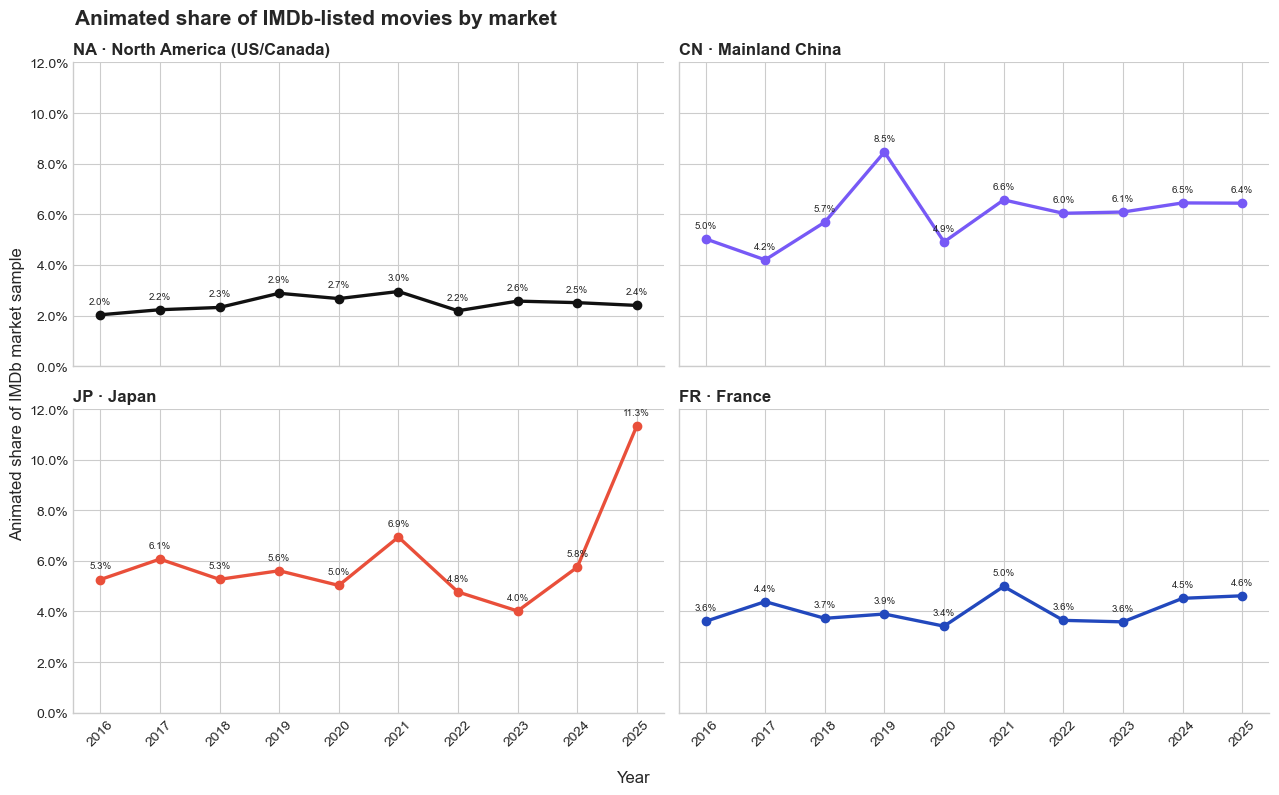

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)

for ax, code_value in zip(axes.flatten(), MARKET_ORDER):
    subset = market.loc[market["market_code"].eq(code_value)].sort_values("year")
    ax.plot(
        subset["year"], subset["animated_share_pct"],
        color=MARKET_COLORS[code_value], marker="o", linewidth=2.4,
    )
    for row in subset.itertuples():
        ax.annotate(
            f"{row.animated_share_pct:.1f}%",
            (row.year, row.animated_share_pct), xytext=(0, 8),
            textcoords="offset points", ha="center", fontsize=7,
        )
    ax.set_title(f"{code_value} · {subset['market'].iloc[0]}", loc="left", weight="bold")
    ax.set_ylim(0, 12)
    ax.set_xticks(EXPECTED_YEARS)
    ax.tick_params(axis="x", rotation=45)
    ax.yaxis.set_major_formatter(PercentFormatter(100))
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Animated share of IMDb-listed movies by market", x=0.07, ha="left", fontsize=15, fontweight="bold")
fig.supxlabel("Year")
fig.supylabel("Animated share of IMDb market sample")
fig.tight_layout()
plt.show()

### 4.2 Combined comparison

The fifth chart shows all four markets together, using the same percentage scale for direct comparison.

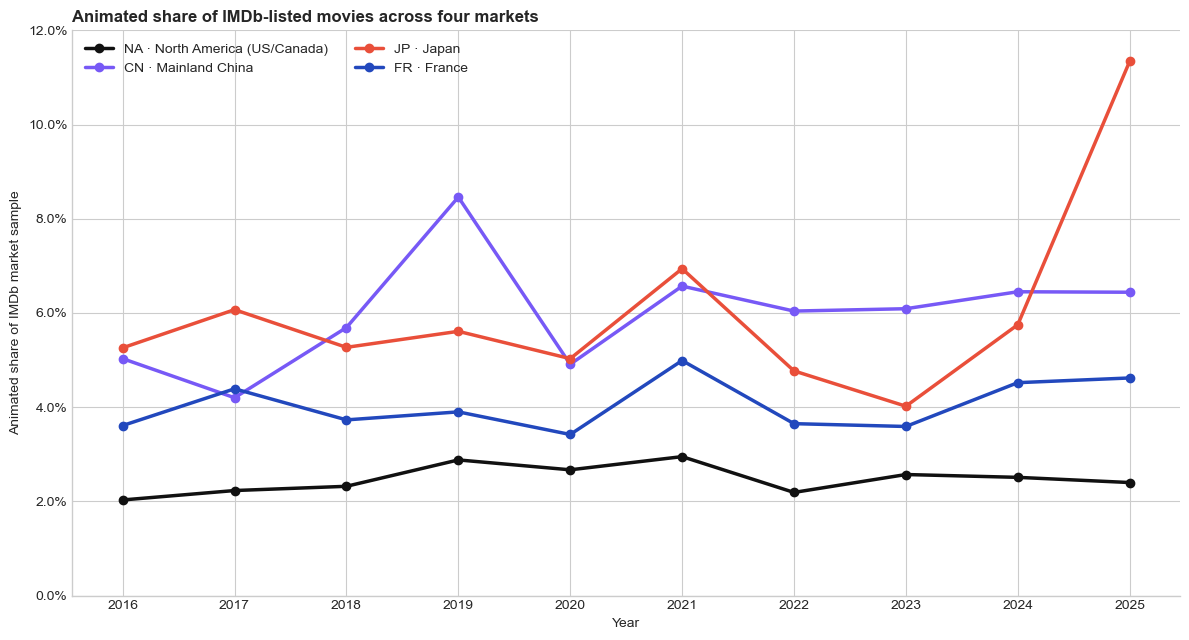

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6.5))

for code_value in MARKET_ORDER:
    subset = market.loc[market["market_code"].eq(code_value)].sort_values("year")
    ax.plot(
        subset["year"], subset["animated_share_pct"],
        color=MARKET_COLORS[code_value], marker="o", linewidth=2.5,
        label=f"{code_value} · {subset['market'].iloc[0]}",
    )

ax.set_title("Animated share of IMDb-listed movies across four markets", loc="left", weight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Animated share of IMDb market sample")
ax.set_xticks(EXPECTED_YEARS)
ax.set_ylim(0, 12)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.legend(frameon=False, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

In [ ]:
print("Average animated share across 2016–2025:")
for row in market_summary.sort_values("average_share_pct", ascending=False).itertuples():
    print(f"- {row.market}: {row.average_share_pct:.2f}%")

peak_rows = market.loc[
    market.groupby("market_code")["animated_share_pct"].idxmax(),
    ["market_code", "market", "year", "animated_share_pct"],
].sort_values("animated_share_pct", ascending=False)
display(peak_rows.style.format({"animated_share_pct": "{:.2f}%"}))

Average animated share across 2016–2025:
- Japan: 6.01%
- Mainland China: 5.99%
- France: 4.04%
- North America (US/Canada): 2.48%


,market_code,market,year,animated_share_pct
29,JP,Japan,2025,11.34%
13,CN,Mainland China,2019,8.46%
35,FR,France,2021,4.99%
5,NA,North America (US/Canada),2021,2.95%


**RQ1 Conclusion.** 

Animation has the largest average presence in the Mainland China and Japan samples (both about 6.0%), followed by France (4.0%) and North America (2.5%). The lines do not show a common upward trend: animation's share changes from year to year and follows a different pattern in each market. As the world's largest film market, North America has the lowest animated-film share among the four samples, remaining consistently low and stable throughout the period. Japan's 2025 peak may be misleading: its IMDb sample falls to 891 films, from 2,330 in 2024.

## 5. RQ2 — Worldwide box-office performance

The sample contains the 20 highest-grossing films in each year according to the Box Office Mojo annual worldwide ranking. Two comparisons are used:

1. Animated films' combined share of each annual Top 20's worldwide gross.
2. The highest-grossing animated and non-animated title in each year.

This measures reported box-office gross, not profitability. Production budgets and marketing costs are not available.

In [ ]:
annual_boxoffice = (
    top20.groupby("year", as_index=False)
    .agg(top20_gross_usd=("worldwide_gross_usd", "sum"), animated_films=("animated", "sum"))
)
animated_gross = (
    top20.loc[top20["animated"]]
    .groupby("year", as_index=False)["worldwide_gross_usd"].sum()
    .rename(columns={"worldwide_gross_usd": "animated_gross_usd"})
)
annual_boxoffice = annual_boxoffice.merge(animated_gross, on="year", how="left")
annual_boxoffice["animated_gross_usd"] = annual_boxoffice["animated_gross_usd"].fillna(0)
annual_boxoffice["non_animated_gross_usd"] = annual_boxoffice["top20_gross_usd"] - annual_boxoffice["animated_gross_usd"]
annual_boxoffice["animated_gross_share"] = annual_boxoffice["animated_gross_usd"] / annual_boxoffice["top20_gross_usd"]
annual_boxoffice["non_animated_gross_share"] = 1 - annual_boxoffice["animated_gross_share"]

display(annual_boxoffice.style.format({
    "top20_gross_usd": "${:,.0f}",
    "animated_gross_usd": "${:,.0f}",
    "non_animated_gross_usd": "${:,.0f}",
    "animated_gross_share": "{:.1%}",
    "non_animated_gross_share": "{:.1%}",
}))

,year,top20_gross_usd,animated_films,animated_gross_usd,non_animated_gross_usd,animated_gross_share,non_animated_gross_share
0,2016,"$14,610,803,599",8,"$6,101,835,804","$8,508,967,795",41.8%,58.2%
1,2017,"$16,431,571,695",3,"$2,377,406,517","$14,054,165,178",14.5%,85.5%
2,2018,"$16,388,379,388",4,"$2,813,428,777","$13,574,950,611",17.2%,82.8%
3,2019,"$18,650,821,699",6,"$5,859,249,542","$12,791,572,157",31.4%,68.6%
4,2020,"$4,855,652,972",5,"$1,192,533,218","$3,663,119,754",24.6%,75.4%
5,2021,"$10,592,341,366",2,"$665,488,976","$9,926,852,390",6.3%,93.7%
6,2022,"$13,538,079,117",5,"$2,144,631,372","$11,393,447,745",15.8%,84.2%
7,2023,"$13,189,672,087",3,"$2,547,769,825","$10,641,902,262",19.3%,80.7%
8,2024,"$13,079,342,190",5,"$5,000,705,574","$8,078,636,616",38.2%,61.8%
9,2025,"$15,822,738,081",3,"$4,927,593,305","$10,895,144,776",31.1%,68.9%


### 5.1 Animation's share of annual Top 20 revenue

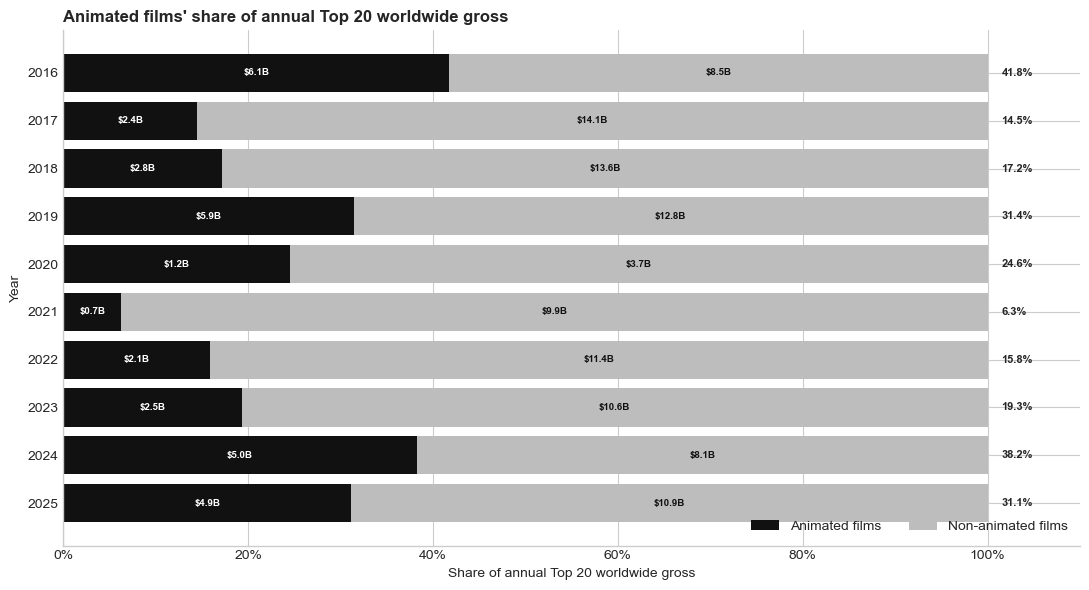

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
years_as_text = annual_boxoffice["year"].astype(str)

ax.barh(years_as_text, annual_boxoffice["animated_gross_share"], color=TYPE_COLORS["Animated"], label="Animated films")
ax.barh(
    years_as_text, annual_boxoffice["non_animated_gross_share"],
    left=annual_boxoffice["animated_gross_share"],
    color=TYPE_COLORS["Non-animated"], label="Non-animated films",
)
for index, row in annual_boxoffice.iterrows():
    ax.text(
        row["animated_gross_share"] / 2,
        index,
        f"${row['animated_gross_usd'] / 1e9:.1f}B",
        ha="center", va="center", color="white", fontsize=7, fontweight="bold",
    )
    ax.text(
        row["animated_gross_share"] + row["non_animated_gross_share"] / 2,
        index,
        f"${row['non_animated_gross_usd'] / 1e9:.1f}B",
        ha="center", va="center", color="#111111", fontsize=7, fontweight="bold",
    )
    ax.text(1.015, index, f"{row['animated_gross_share']:.1%}", va="center", fontsize=8, fontweight="bold")

ax.set_title("Animated films' share of annual Top 20 worldwide gross", loc="left", weight="bold")
ax.set_xlabel("Share of annual Top 20 worldwide gross")
ax.set_ylabel("Year")
ax.set_xlim(0, 1.1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.invert_yaxis()
ax.legend(frameon=False, ncol=2, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

### 5.2 Highest-grossing title in each category

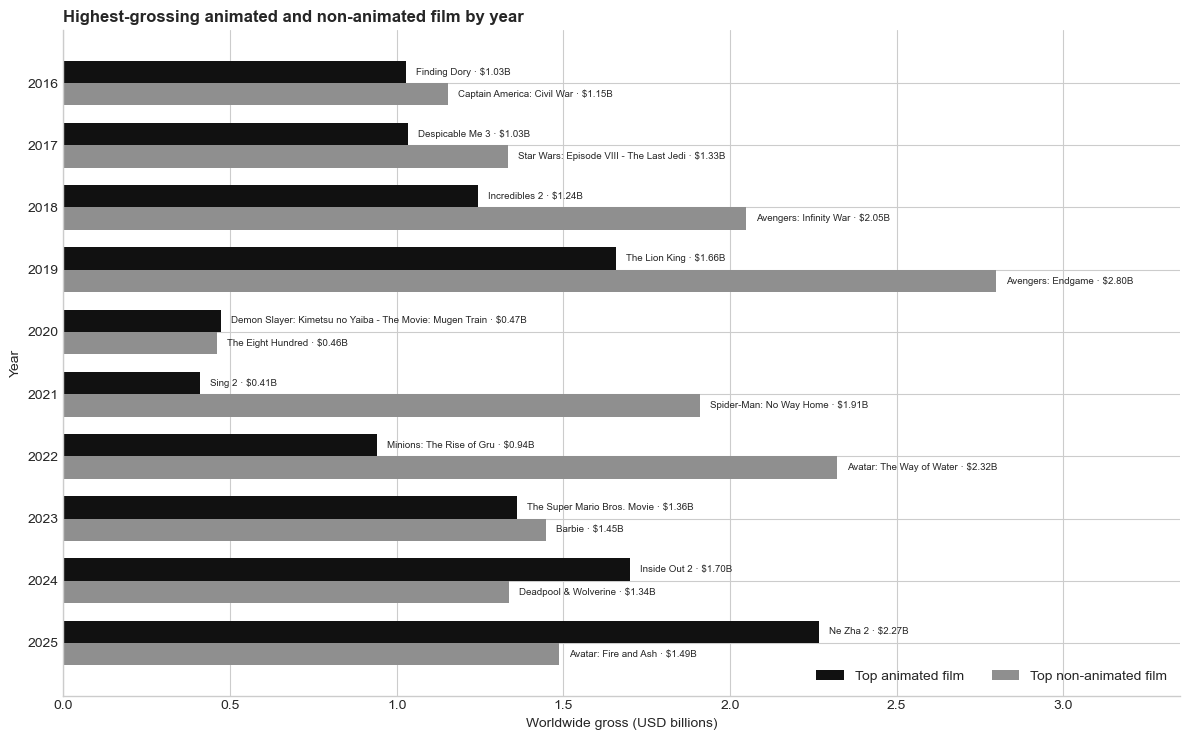

In [ ]:
leaders = (
    top20.sort_values("worldwide_gross_usd", ascending=False)
    .groupby(["year", "film_type"], as_index=False).first()
)
animated_leaders = leaders.loc[leaders["film_type"].eq("Animated")].set_index("year").reindex(EXPECTED_YEARS)
non_animated_leaders = leaders.loc[leaders["film_type"].eq("Non-animated")].set_index("year").reindex(EXPECTED_YEARS)

y = np.arange(len(EXPECTED_YEARS))
height = 0.36
fig, ax = plt.subplots(figsize=(12, 7.5))
ax.barh(y - height / 2, animated_leaders["worldwide_gross_usd"] / 1e9, height=height, color="#111111", label="Top animated film")
ax.barh(y + height / 2, non_animated_leaders["worldwide_gross_usd"] / 1e9, height=height, color="#8f8f8f", label="Top non-animated film")

for index, year in enumerate(EXPECTED_YEARS):
    animated_row = animated_leaders.loc[year]
    non_animated_row = non_animated_leaders.loc[year]
    ax.text(animated_row["worldwide_gross_usd"] / 1e9 + 0.03, index - height / 2, f"{animated_row['title']} · ${animated_row['worldwide_gross_usd'] / 1e9:.2f}B", va="center", fontsize=7)
    ax.text(non_animated_row["worldwide_gross_usd"] / 1e9 + 0.03, index + height / 2, f"{non_animated_row['title']} · ${non_animated_row['worldwide_gross_usd'] / 1e9:.2f}B", va="center", fontsize=7)

ax.set_yticks(y, EXPECTED_YEARS)
ax.set_xlim(0, 3.35)
ax.invert_yaxis()
ax.set_title("Highest-grossing animated and non-animated film by year", loc="left", weight="bold")
ax.set_xlabel("Worldwide gross (USD billions)")
ax.set_ylabel("Year")
ax.legend(frameon=False, ncol=2, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

In [ ]:
highest_share = annual_boxoffice.loc[annual_boxoffice["animated_gross_share"].idxmax()]
lowest_share = annual_boxoffice.loc[annual_boxoffice["animated_gross_share"].idxmin()]
print(f"Highest animated contribution: {int(highest_share['year'])} ({highest_share['animated_gross_share']:.1%})")
print(f"Lowest animated contribution: {int(lowest_share['year'])} ({lowest_share['animated_gross_share']:.1%})")

Highest animated contribution: 2016 (41.8%)
Lowest animated contribution: 2021 (6.3%)


**RQ2 Conclusion.** 

The top non-animated film led in seven of the ten years, but animation overtook it in 2020, 2024 and 2025. The back-to-back wins in 2024–2025, culminating in Ne Zha 2 at $2.27B, show that animation can produce not only a large revenue share, but also the year's single highest-grossing record.

## 6. RQ3 — Production companies behind top animated films

**Figure definitions**

44 = animated records within the 200 annual Top 20 records, classified by the IMDb Animation genre; 42 of 44 = animated records with at least one Wikidata production-company credit; 24 = different production-company names found across those 42 films. Related companies are counted separately.

**Why a bar chart rather than a pie chart?** 

A co-produced film can count toward several companies, so these percentages overlap and may total more than 100%. A pie chart would wrongly imply mutually exclusive parts of one whole; bars compare the non-exclusive company credits accurately. Company labels are not merged into corporate groups.

In [ ]:
COMPANY_LABEL_FIXES = {"Q1047410": "Walt Disney Animation Studios"}

animated_films = top20.loc[top20["animated"]].copy()
animated_films["company"] = animated_films["production_companies"].str.split(" | ", regex=False)
company_credits = animated_films.explode("company")
company_credits["company"] = company_credits["company"].str.strip().replace(COMPANY_LABEL_FIXES)
company_credits = company_credits.loc[company_credits["company"].ne("")]

company_ranking = (
    company_credits.groupby("company").size()
    .rename("animated_top20_films").sort_values(ascending=False).to_frame()
)
company_ranking["share_of_44_animated_records"] = company_ranking["animated_top20_films"] / len(animated_films)

print(f"Animated films in the Top 20 dataset: {len(animated_films)}")
print(f"Animated films with company data: {animated_films['production_companies'].ne('').sum()}")
print(f"Distinct company labels: {len(company_ranking)}")
display(company_ranking.head(15).style.format({"share_of_44_animated_records": "{:.1%}"}))

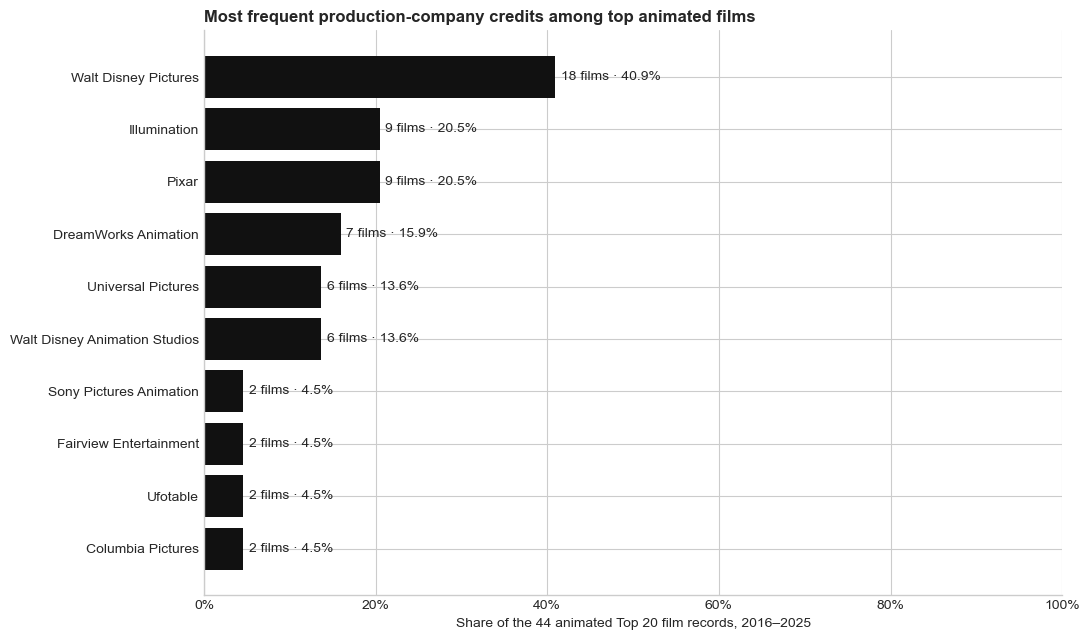

In [ ]:
top_companies = company_ranking.head(10).sort_values("animated_top20_films")
fig, ax = plt.subplots(figsize=(11, 6.5))
bars = ax.barh(top_companies.index, top_companies["share_of_44_animated_records"], color="#111111")
labels = [
    f"{count} films · {share:.1%}"
    for count, share in zip(
        top_companies["animated_top20_films"],
        top_companies["share_of_44_animated_records"],
    )
]
ax.bar_label(bars, labels=labels, padding=4)
ax.set_title("Most frequent production-company credits among top animated films", loc="left", weight="bold")
ax.set_xlabel("Share of the 44 animated Top 20 film records, 2016–2025")
ax.set_ylabel("")
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

In [ ]:
def count_labels_containing(term):
    mask = company_ranking.index.str.contains(term, case=False, regex=False)
    return int(company_ranking.loc[mask, "animated_top20_films"].sum())

named_company_counts = pd.Series({
    "Walt Disney Pictures": int(company_ranking["animated_top20_films"].get("Walt Disney Pictures", 0)),
    "Walt Disney Animation Studios": int(company_ranking["animated_top20_films"].get("Walt Disney Animation Studios", 0)),
    "Pixar": int(company_ranking["animated_top20_films"].get("Pixar", 0)),
    "Marvel-labelled companies": count_labels_containing("Marvel"),
}, name="animated Top 20 film credits")
display(named_company_counts.to_frame())

,animated Top 20 film credits
Walt Disney Pictures,18
Walt Disney Animation Studios,6
Pixar,9
Marvel-labelled companies,1


**RQ3 Conclusion.** 

Walt Disney Pictures is the most frequent credit, appearing on 18 of the 44 animated films. Pixar appears on 9; Marvel-labelled companies appear on 1. Disney and Pixar are prominent in this sample, but the ranking also shows substantial activity from Illumination, DreamWorks Animation and other producers.

## 7. Appendix — Animated films in the annual rankings

This section is a reference appendix rather than a separate research question.

It lists every title classified as animated within the 200 annual ranking records used for RQ2 and RQ3, allowing readers to inspect the films behind the box-office and producer analyses. Select a year to narrow the table.

In [ ]:
animated_reference = (
    animated_films[[
        "year", "annual_rank", "title", "worldwide_gross_usd",
        "imdb_id", "wikidata_qid", "production_companies"
    ]]
    .sort_values(["year", "annual_rank"]).reset_index(drop=True)
)
display(animated_reference.style.format({"worldwide_gross_usd": "${:,.0f}"}))

,year,annual_rank,title,worldwide_gross_usd,imdb_id,wikidata_qid,production_companies
0,2016,3,Finding Dory,"$1,028,570,889",tt2277860,Q9321426,Pixar | Walt Disney Pictures
1,2016,4,Zootopia,"$1,023,784,195",tt2948356,Q15270647,Walt Disney Pictures | Q1047410
2,2016,5,The Jungle Book,"$966,550,600",tt3040964,Q16857406,Walt Disney Pictures | Shepperton Studios | Disney Character Voices International | Fairview Entertainment | SDI Media Iberia
3,2016,6,The Secret Life of Pets,"$875,697,467",tt2709768,Q18844656,Illumination
4,2016,12,Moana,"$643,331,111",tt3521164,Q18647981,Walt Disney Pictures | Q1047410
5,2016,13,Sing,"$634,151,679",tt3470600,Q20762698,Universal Pictures | Illumination
6,2016,16,Kung Fu Panda 3,"$521,170,825",tt2267968,Q15055043,DreamWorks Animation
7,2016,20,Ice Age: Collision Course,"$408,579,038",tt3416828,Q15965953,20th Century Animation | Blue Sky Studios
8,2017,4,Despicable Me 3,"$1,034,799,409",tt3469046,Q22997984,Illumination
9,2017,11,Coco,"$814,641,172",tt2380307,Q5815826,Pixar | Walt Disney Pictures


## Limitations and conclusions

### Limitations

- RQ1 counts films linked to each market through IMDb title records; it does not show the official number of films produced or released in cinemas there.
- Recent-year IMDb records, especially 2025, may be less complete.
- Box-office gross is revenue, not profit; costs are not included.
- RQ2 and RQ3 describe only the annual worldwide Top 20.
- Animation classification follows the IMDb genre.
- Wikidata production-company credits may be incomplete.
- Company labels are not merged into corporate groups and co-production counts overlap.

### Conclusions
1. Animation's share varies across the four IMDb market samples; Japan and Mainland China have the highest ten-year averages in this sample.
2. Animated films' contribution to the annual worldwide Top 20 changes greatly from year to year, and a few highly successful titles can create a large annual revenue share.
3. Disney- and Pixar-labeled entities remain prominent, but Illumination, DreamWorks Animation and others also appear repeatedly. Marvel is not dominant in this animated sample.